In [1]:
# import for creating MLP classifier of news groups dataset
import numpy as np
import matplotlib.pylab as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import fetch_20newsgroups
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score, precision_score

In [3]:
# data set of news posts posted to one of twenty different groups
# the "fetcher" gathers the training or the test set
newsgroups_train = fetch_20newsgroups(subset='train')

In [51]:
print('fetch returns:',type(newsgroups_train))
print(len(newsgroups_train.target), 'data points')
print(newsgroups_train.target_names)

fetch returns: <class 'sklearn.utils._bunch.Bunch'>
11314 data points
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [45]:
# print an example of data point:
example = 123
print(f'data entry {example}')
print(f'classification: type {newsgroups_train.target[example]}: {newsgroups_train.target_names[ newsgroups_train.target[example] ]}' )
print('\n'+newsgroups_train.data[example])

data entry 123
classification: type 15: soc.religion.christian

From: JEK@cu.nih.gov
Subject: John 3:16 paraphrased
Lines: 25

At the end of a recent (Mon 19 Apr 1993) post, Alastair Thomson
offers the following "paraphrase" of John 3:16:

   "God loved the world so much, that he gave us His Son,
   to die in our place, so that we may have eternal life."

The "to die in our place" bothers me, since it inserts into the
verse a doctrine not found in the original. Moreover, I suspect that
the poster intends to affirm, not merely substitution, but forensic
(or penal) substitution.  I maintain that the Scriptures in speaking
of the Atonement teach a doctrine of Substitution, but not one of
Forensic Substitution.

Those interested in pursuing the matter are invited to send for my
essays on Genesis, either 4 thru 7 (on this question) or 1 through 7
(with lead-in).  The n'th essay can be obtained by sending to
LISTSERV@ASUACAD.BITNET or to LISTSERV@ASUVM.INRE.ASU.EDU the
message
   GET GEN0n R

In [61]:
# create and apply MLP
hiddenLayerSizes = (7)
activ = 'relu'
solv = 'lbfgs'
randomState = 2
maxIter = 800
#
mlpc = MLPClassifier( hidden_layer_sizes = hiddenLayerSizes, \
                        activation = activ, \
                        solver = solv, \
                        random_state = randomState, \
                        max_iter = maxIter
                    )
mlpc.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=7, max_iter=800, random_state=2,
              solver='lbfgs')

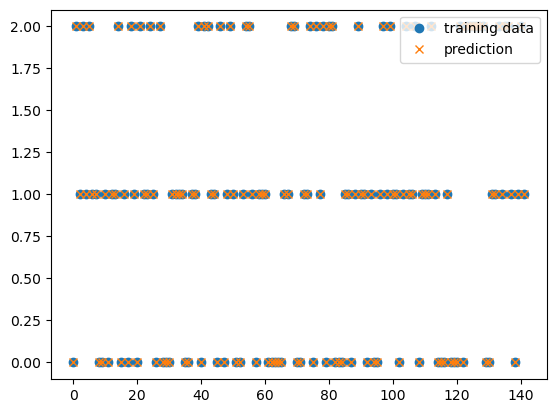

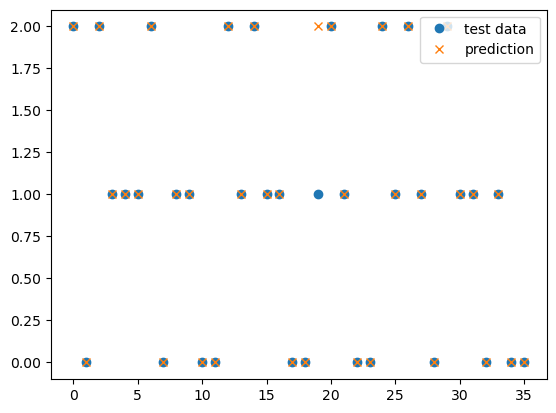

In [63]:
# try prediction on the training and test sets - plot results
predictions = {}  # create dictionary with predictions
for X_split, y_split, label in [[X_train,y_train,'training'], [X_test,y_test,'test']]:
    predictions[label] = mlpc.predict(X_split)
    plt.plot(y_split,'o',label=label+' data')
    plt.plot(predictions[label],'x',label='prediction')
    plt.legend(loc='upper right')
    plt.show()

In [66]:
# evaluate with metrics
CM={}
for y, label in [[y_train,'training'], [y_test,'test']]:
    CM[label] = confusion_matrix(y, predictions[label])
    print(label+' data'); print(CM[label])

training data
[[47  0  0]
 [ 0 56  0]
 [ 0  0 39]]
test data
[[12  0  0]
 [ 0 14  1]
 [ 0  0  9]]


In [82]:
# determine recall and precision for model
print('recall   :',recall_score(y_test,predictions['test'],average=None))
print('precision:',precision_score(y_test,predictions['test'],average=None))

recall   : [1.         0.93333333 1.        ]
precision: [1.  1.  0.9]
